<a href="https://colab.research.google.com/github/ary3120-droid/myproject/blob/main/stl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1) 데이터 로드 및 기본 정리

2) 매출 시계열 만들기

여기서는 df1_순매출을 STL 대상 변수로 사용한다.

In [13]:
df = pd.read_csv('/content/drive/MyDrive/project_data/preprocessed_main.csv')

# 날짜형 변환
df['날짜'] = pd.to_datetime(df['날짜'])

# 날짜순 정렬
df = df.sort_values('날짜').reset_index(drop=True)

print(df.shape)
print(df[['날짜', 'sales_amount']].head())
print(df[['날짜', 'sales_amount']].tail())

(444, 53)
          날짜  sales_amount
0 2024-10-14     1789250.0
1 2024-10-15      520000.0
2 2024-10-16           0.0
3 2024-10-17      620000.0
4 2024-10-18     1283000.0
            날짜  sales_amount
439 2025-12-27           0.0
440 2025-12-28      678000.0
441 2025-12-29           0.0
442 2025-12-30           0.0
443 2025-12-31     1285000.0


##1. STL용 시계열 만들기
1. STL용 시계열 만들기

In [15]:
# STL용 시계열
ts = df[['날짜', 'sales_amount']].copy()

# 결측은 0 처리
ts['sales_amount'] = ts['sales_amount'].fillna(0)

# 날짜 인덱스 설정
ts = ts.set_index('날짜')

# 일 단위 연속 인덱스 생성
full_idx = pd.date_range(ts.index.min(), ts.index.max(), freq='D')
ts = ts.reindex(full_idx)

# 중간 날짜 매출 결측도 0 처리
ts['sales_amount'] = ts['sales_amount'].fillna(0)

# 인덱스 이름 복원
ts.index.name = '날짜'

print(ts.head())
print(ts.tail())

            sales_amount
날짜                      
2024-10-14     1789250.0
2024-10-15      520000.0
2024-10-16           0.0
2024-10-17      620000.0
2024-10-18     1283000.0
            sales_amount
날짜                      
2025-12-27           0.0
2025-12-28      678000.0
2025-12-29           0.0
2025-12-30           0.0
2025-12-31     1285000.0


##2. 원 시계열 확인

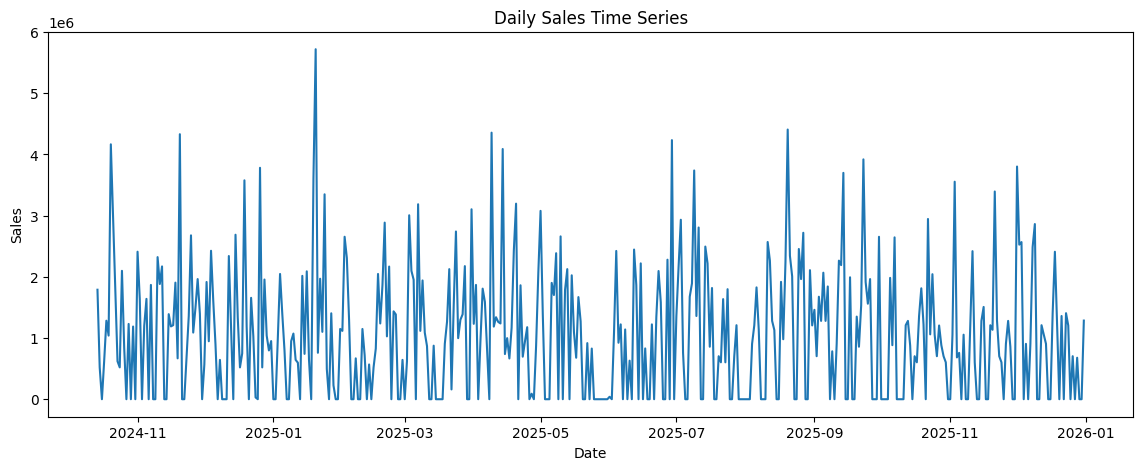

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(ts.index, ts['sales_amount'])
plt.title("Daily Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

##3. STL 분해

period=7, robust=True 유지

In [18]:
stl = STL(ts['sales_amount'], period=7, robust=True)
result = stl.fit()

ts['trend'] = result.trend
ts['seasonal'] = result.seasonal
ts['resid'] = result.resid

##4. STL 결과 시각화

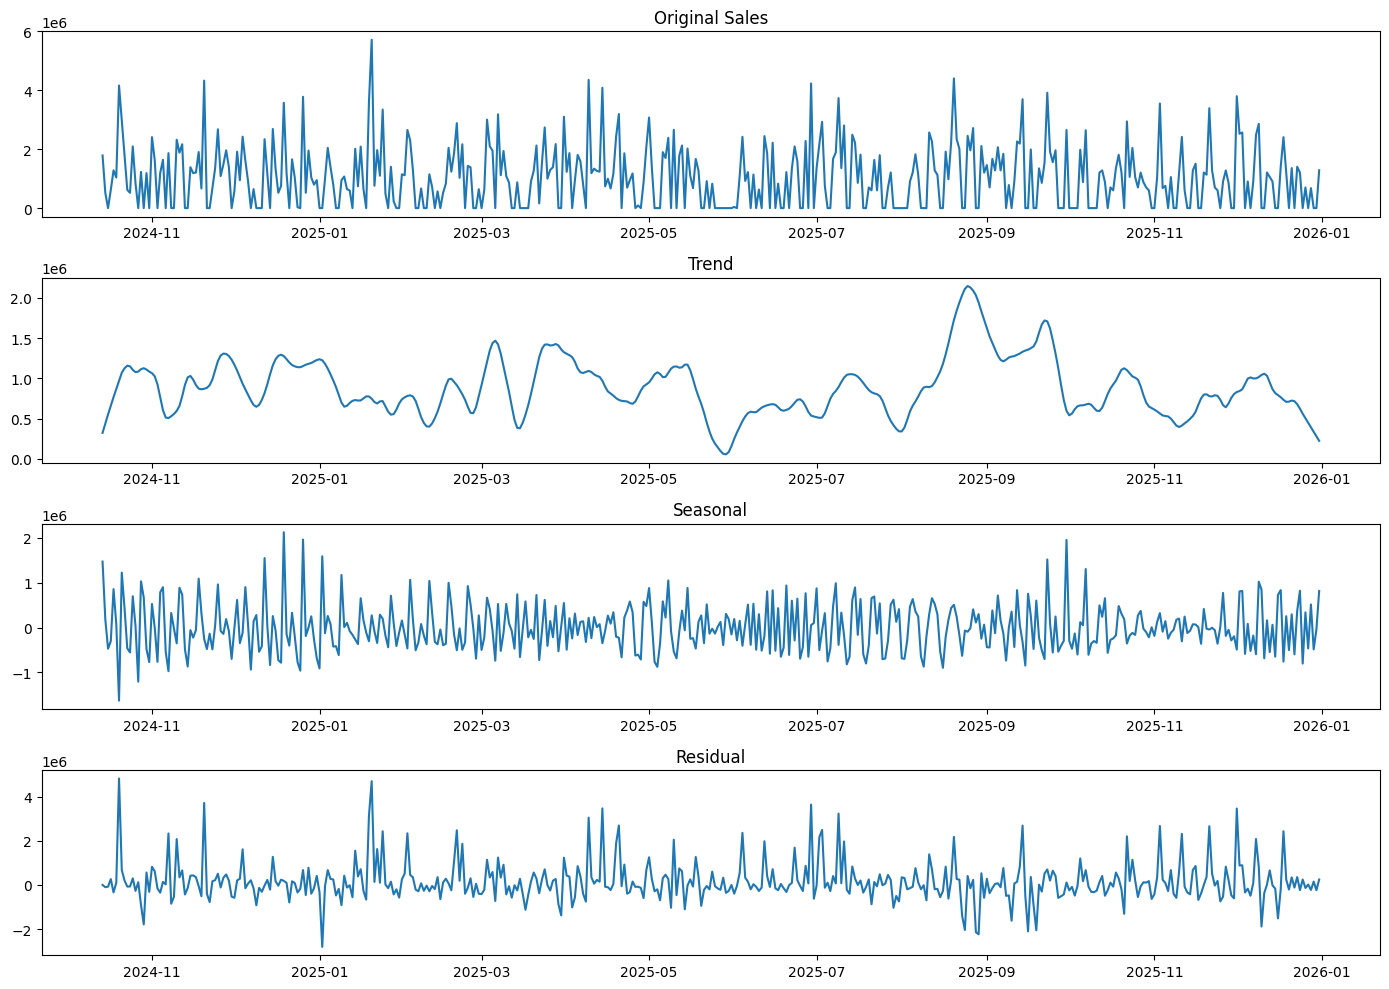

In [19]:
plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(ts.index, ts['sales_amount'])
plt.title("Original Sales")

plt.subplot(4, 1, 2)
plt.plot(ts.index, ts['trend'])
plt.title("Trend")

plt.subplot(4, 1, 3)
plt.plot(ts.index, ts['seasonal'])
plt.title("Seasonal")

plt.subplot(4, 1, 4)
plt.plot(ts.index, ts['resid'])
plt.title("Residual")

plt.tight_layout()
plt.show()

##5. 1단계: 초과매출 라벨 생성
residual 상위 5%를 임시 기준으로 둔다.


In [20]:
threshold = ts['resid'].quantile(0.95)
ts['excess_label'] = (ts['resid'] > threshold).astype(int)

print("Residual 95% threshold:", threshold)
print(ts['excess_label'].value_counts())
print("초과매출 비율:", ts['excess_label'].mean())

Residual 95% threshold: 2176040.5838369387
excess_label
0    421
1     23
Name: count, dtype: int64
초과매출 비율: 0.0518018018018018


In [21]:
# 초과매출 후보일 확인
excess_dates = ts[ts['excess_label'] == 1].index
print(excess_dates)

DatetimeIndex(['2024-10-20', '2024-11-07', '2024-11-20', '2025-01-19',
               '2025-01-20', '2025-01-24', '2025-02-02', '2025-02-20',
               '2025-04-09', '2025-04-14', '2025-04-20', '2025-06-04',
               '2025-06-29', '2025-07-03', '2025-07-09', '2025-08-20',
               '2025-09-14', '2025-10-22', '2025-11-03', '2025-11-11',
               '2025-11-21', '2025-12-01', '2025-12-18'],
              dtype='datetime64[ns]', name='날짜', freq=None)


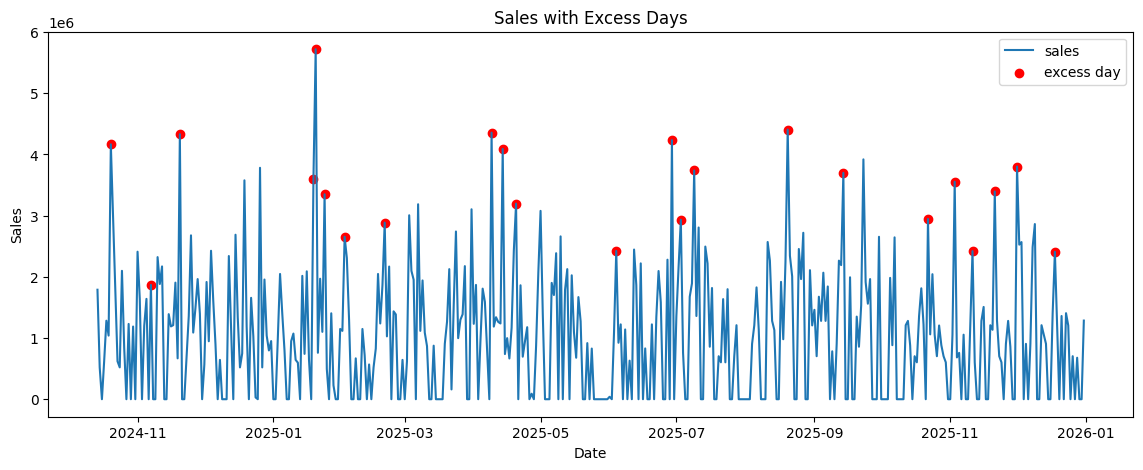

In [22]:
plt.figure(figsize=(14, 5))
plt.plot(ts.index, ts['sales_amount'], label='sales')
plt.scatter(
    ts.index[ts['excess_label'] == 1],
    ts.loc[ts['excess_label'] == 1, 'sales_amount'],
    color='red',
    label='excess day'
)
plt.title("Sales with Excess Days")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

##6. STL 결과를 원본 데이터에 붙이기

In [23]:
ts_reset = ts.reset_index()

df_model = pd.merge(
    df,
    ts_reset[['날짜', 'trend', 'seasonal', 'resid', 'excess_label']],
    on='날짜',
    how='right'
)

print(df_model.shape)
print(df_model[['날짜', 'sales_amount', 'excess_label']].head())

(444, 57)
          날짜  sales_amount  excess_label
0 2024-10-14     1789250.0             0
1 2024-10-15      520000.0             0
2 2024-10-16           0.0             0
3 2024-10-17      620000.0             0
4 2024-10-18     1283000.0             0


##7. 2단계: 초과 있음 vs 없음 비교
7-1. 평균 비교

In [24]:
compare_cols = [
    'sales_amount',
    'refund_amount',
    'net_sales',
    'refund_rate',
    'buyer_count',
    'order_count',
    'item_count',
    'AOV',
    'items_per_order',
    'product_mix',
    'marketing_cost'
]

group_mean = df_model.groupby('excess_label')[compare_cols].mean()
print(group_mean)

              sales_amount  refund_amount     net_sales  refund_rate  \
excess_label                                                           
0             1.045463e+06  186043.256997  8.810694e+05     0.141821   
1             3.486033e+06  655556.818182  2.904023e+06     0.181831   

              buyer_count  order_count  item_count           AOV  \
excess_label                                                       
0                1.729614     1.858369    5.184549  7.682280e+05   
1                2.705882     3.000000    9.000000  1.660465e+06   

              items_per_order  product_mix  marketing_cost  
excess_label                                                
0                    2.764378     6.935867    63789.878049  
1                    3.622549     3.608696    67661.869565  


##7-2. 중앙값 비교

In [25]:
group_median = df_model.groupby('excess_label')[compare_cols].median()
print(group_median)

              sales_amount  refund_amount  net_sales  refund_rate  \
excess_label                                                        
0                1027000.0            0.0   879000.0          0.0   
1                3554500.0            0.0  3000875.0          0.0   

              buyer_count  order_count  item_count           AOV  \
excess_label                                                       
0                     1.0          2.0         4.0  6.780000e+05   
1                     3.0          3.0         7.0  1.116167e+06   

              items_per_order  product_mix  marketing_cost  
excess_label                                                
0                    2.500000          1.0         55523.5  
1                    2.666667          4.0         60000.0  


##7-3. 비율 플래그 생성 후 비교

“초과 있을 때 / 없을 때 비율”을 보기 위한 단계

In [26]:
df_model['high_AOV_flag'] = (df_model['AOV'] > df_model['AOV'].median()).astype(int)
df_model['high_buyer_flag'] = (df_model['buyer_count'] > df_model['buyer_count'].median()).astype(int)
df_model['high_order_flag'] = (df_model['order_count'] > df_model['order_count'].median()).astype(int)
df_model['high_mix_flag'] = (df_model['product_mix'] > df_model['product_mix'].median()).astype(int)
df_model['refund_flag'] = (df_model['refund_amount'] > 0).astype(int)

ratio_cols = [
    'high_AOV_flag',
    'high_buyer_flag',
    'high_order_flag',
    'high_mix_flag',
    'refund_flag'
]

ratio_compare = df_model.groupby('excess_label')[ratio_cols].mean() * 100
print(ratio_compare)

              high_AOV_flag  high_buyer_flag  high_order_flag  high_mix_flag  \
excess_label                                                                   
0                 22.565321         9.738717        11.401425        30.4038   
1                 69.565217        39.130435        43.478261       100.0000   

              refund_flag  
excess_label               
0               16.152019  
1               34.782609  


##8. 3단계: 초과가 전체를 얼마나 바꾸는지 확인
8-1. 초과일의 전체 매출 기여도

In [27]:
total_sales = df_model['sales_amount'].sum()
excess_sales = df_model.loc[df_model['excess_label'] == 1, 'sales_amount'].sum()
normal_sales = df_model.loc[df_model['excess_label'] == 0, 'sales_amount'].sum()

print("전체 매출:", total_sales)
print("초과일 매출:", excess_sales)
print("일반일 매출:", normal_sales)
print("초과일 매출 기여도(%):", excess_sales / total_sales * 100)

전체 매출: 468045500.0
초과일 매출: 80178750.0
일반일 매출: 387866750.0
초과일 매출 기여도(%): 17.13054606870486


#8-2. 초과일의 전체 환불 기여도

In [28]:
total_refund = df_model['refund_amount'].fillna(0).sum()
excess_refund = df_model.loc[df_model['excess_label'] == 1, 'refund_amount'].fillna(0).sum()

print("전체 환불:", total_refund)
print("초과일 환불:", excess_refund)
print("초과일 환불 기여도(%):", excess_refund / total_refund * 100 if total_refund != 0 else 0)

전체 환불: 87537250.0
초과일 환불: 14422250.0
초과일 환불 기여도(%): 16.475557548357987


##8-3. 초과 제외 전후 평균/중앙값 비교

In [29]:
print("전체 평균 매출:", df_model['sales_amount'].mean())
print("초과 제외 평균 매출:", df_model.loc[df_model['excess_label'] == 0, 'sales_amount'].mean())

print("전체 중앙값 매출:", df_model['sales_amount'].median())
print("초과 제외 중앙값 매출:", df_model.loc[df_model['excess_label'] == 0, 'sales_amount'].median())

print("전체 평균 AOV:", df_model['AOV'].mean())
print("초과 제외 평균 AOV:", df_model.loc[df_model['excess_label'] == 0, 'AOV'].mean())

전체 평균 매출: 1187932.7411167512
초과 제외 평균 매출: 1045462.9380053908
전체 중앙값 매출: 1093625.0
초과 제외 중앙값 매출: 1027000.0
전체 평균 AOV: 836552.4211711711
초과 제외 평균 AOV: 768227.9674796748


##9. 4단계: 스파이크 발생 텀 변수 만들기
9-1. 직전 스파이크 이후 경과일

In [30]:
df_model = df_model.sort_values('날짜').reset_index(drop=True)

df_model['days_since_last_spike'] = np.nan
last_spike_date = None

for i in range(len(df_model)):
    current_date = df_model.loc[i, '날짜']
    current_label = df_model.loc[i, 'excess_label']

    if last_spike_date is not None:
        df_model.loc[i, 'days_since_last_spike'] = (current_date - last_spike_date).days

    if current_label == 1:
        last_spike_date = current_date

##9-2. 다음 스파이크까지 남은 일수

In [32]:
df_model['days_until_next_spike'] = np.nan
next_spike_date = None

for i in range(len(df_model)-1, -1, -1):
    current_date = df_model.loc[i, '날짜']
    current_label = df_model.loc[i, 'excess_label']

    if next_spike_date is not None:
        df_model.loc[i, 'days_until_next_spike'] = (next_spike_date - current_date).days

    if current_label == 1:
        next_spike_date = current_date

##9-3. 전후 간격 튜플

In [33]:
df_model['spike_gap_tuple'] = list(zip(
    df_model['days_since_last_spike'],
    df_model['days_until_next_spike']
))

print(df_model[['날짜', 'excess_label', 'days_since_last_spike', 'days_until_next_spike', 'spike_gap_tuple']].head(20))

           날짜  excess_label  days_since_last_spike  days_until_next_spike  \
0  2024-10-14             0                    NaN                    6.0   
1  2024-10-15             0                    NaN                    5.0   
2  2024-10-16             0                    NaN                    4.0   
3  2024-10-17             0                    NaN                    3.0   
4  2024-10-18             0                    NaN                    2.0   
5  2024-10-19             0                    NaN                    1.0   
6  2024-10-20             1                    NaN                   18.0   
7  2024-10-21             0                    1.0                   17.0   
8  2024-10-22             0                    2.0                   16.0   
9  2024-10-23             0                    3.0                   15.0   
10 2024-10-24             0                    4.0                   14.0   
11 2024-10-25             0                    5.0                   13.0   

##9-4. 최근 7일, 30일 내 스파이크 횟수

In [34]:
df_model['rolling_spike_7d'] = df_model['excess_label'].rolling(7, min_periods=1).sum()
df_model['rolling_spike_30d'] = df_model['excess_label'].rolling(30, min_periods=1).sum()

##9-5. 연속 스파이크 여부

In [35]:
df_model['is_consecutive_spike'] = (
    (df_model['excess_label'] == 1) &
    (df_model['excess_label'].shift(1) == 1)
).astype(int)

##10. 5단계: 조합 피처 생성

In [36]:
df_model['buyer_AOV_interaction'] = df_model['buyer_count'] * df_model['AOV']
df_model['mix_AOV_interaction'] = df_model['product_mix'] * df_model['AOV']
df_model['order_item_interaction'] = df_model['order_count'] * df_model['items_per_order']
df_model['buyer_mix_interaction'] = df_model['buyer_count'] * df_model['product_mix']

#시간 변수도 추가
df_model['weekday'] = df_model['날짜'].dt.weekday
df_model['month'] = df_model['날짜'].dt.month

##11. 6단계: RandomForest로 설명
11-1. 모델용 피처 선택

In [37]:
feature_cols = [
    'buyer_count',
    'order_count',
    'item_count',
    'AOV',
    'items_per_order',
    'product_mix',
    'marketing_cost',
    'refund_rate',
    'days_since_last_spike',
    'days_until_next_spike',
    'rolling_spike_7d',
    'rolling_spike_30d',
    'is_consecutive_spike',
    'buyer_AOV_interaction',
    'mix_AOV_interaction',
    'order_item_interaction',
    'buyer_mix_interaction',
    'weekday',
    'month'
]

##11-2. X, y 만들기

In [38]:
X = df_model[feature_cols].copy()
y = df_model['excess_label'].copy()

# 결측 0 처리
X = X.fillna(0)

print(X.shape, y.shape)

(444, 19) (444,)


##11-3. train/test split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##11-4. 모델 학습

In [41]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=3,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=6, min_samples_leaf=3,
                       n_estimators=300, random_state=42)

##11-5. 예측 성능 확인

In [42]:
y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[84  0]
 [ 4  1]]
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        84
           1       1.00      0.20      0.33         5

    accuracy                           0.96        89
   macro avg       0.98      0.60      0.66        89
weighted avg       0.96      0.96      0.94        89



##11-6. 변수 중요도 확인

In [43]:
importance = pd.Series(
    rf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print(importance)

buyer_AOV_interaction     0.188829
product_mix               0.168644
mix_AOV_interaction       0.144786
rolling_spike_7d          0.127924
AOV                       0.088256
buyer_mix_interaction     0.056196
days_since_last_spike     0.040596
days_until_next_spike     0.032203
item_count                0.024878
order_item_interaction    0.022594
rolling_spike_30d         0.018171
marketing_cost            0.017363
order_count               0.015814
items_per_order           0.014351
month                     0.012757
weekday                   0.012344
buyer_count               0.011105
refund_rate               0.003189
is_consecutive_spike      0.000000
dtype: float64


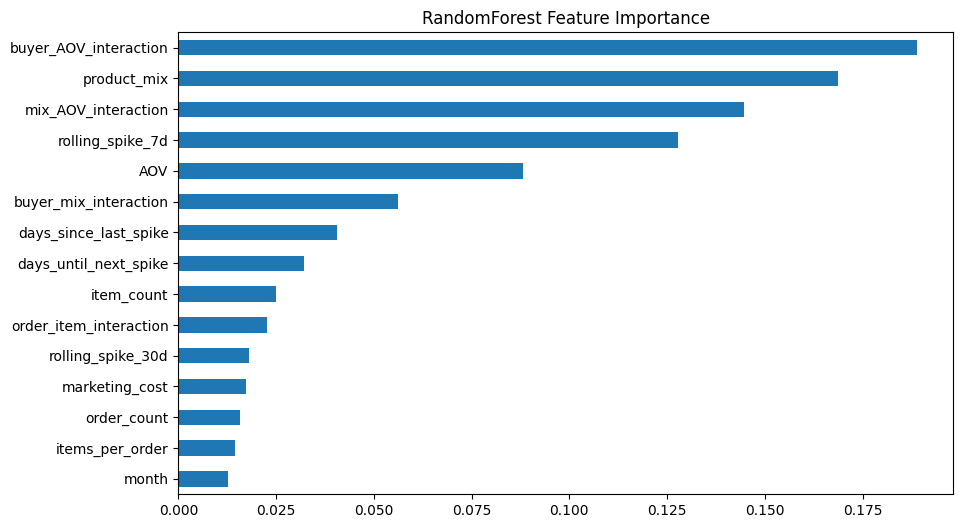

In [44]:
plt.figure(figsize=(10, 6))
importance.head(15).sort_values().plot(kind='barh')
plt.title("RandomForest Feature Importance")
plt.show()

초과 있음 vs 없음 비교

초과일에서 AOV, buyer_count, order_count 비율이 더 높은가

초과일에서 refund_flag가 더 자주 나타나는가

product_mix가 높을 때 초과가 더 많이 발생하는가

초과가 전체를 바꾸는 정도

초과일이 전체 매출의 몇 %를 차지하는가

초과일 제외 시 평균 매출이 얼마나 내려가는가

초과일이 환불 구조까지 크게 흔드는가

스파이크 텀

최근 7일/30일 내 스파이크 경험이 설명력이 있는가

스파이크가 특정 간격으로 반복되는가

연속 스파이크가 있는가

조합 피처

buyer_AOV_interaction 중요도 높음
→ 구매자 수와 객단가가 동시에 커질 때 초과가 잘 생김

mix_AOV_interaction 중요도 높음
→ 제품조합 확대가 고가 구매와 결합될 때 초과가 잘 생김

In [46]:
analysis_note = """
본 분석에서는 STL 분해를 통해 잔차가 큰 날짜를 초과매출 후보일로 임시 라벨링하였다.
이후 초과매출일과 일반일을 비교하여 구매자 구조, 주문수, 객단가, 제품조합, 환불 여부 등의 차이를 확인하고,
초과매출이 전체 매출 및 환불 구조에 미치는 영향을 함께 검토하였다.
또한 직전 스파이크 이후 경과일, 다음 스파이크까지의 일수, 최근 7일 및 30일 내 스파이크 빈도 등의 시간 변수와
구매자수×객단가, 제품조합×객단가 등의 조합 피처를 추가 생성하여,
초과매출이 단일 값이 아닌 시간적 맥락과 구조적 조합 속에서 발생하는 현상인지 탐색하였다.
마지막으로 RandomForest를 활용하여 초과매출 발생을 설명하는 주요 변수와 변수 조합을 확인하였다.
"""
print(analysis_note)


본 분석에서는 STL 분해를 통해 잔차가 큰 날짜를 초과매출 후보일로 임시 라벨링하였다.
이후 초과매출일과 일반일을 비교하여 구매자 구조, 주문수, 객단가, 제품조합, 환불 여부 등의 차이를 확인하고,
초과매출이 전체 매출 및 환불 구조에 미치는 영향을 함께 검토하였다.
또한 직전 스파이크 이후 경과일, 다음 스파이크까지의 일수, 최근 7일 및 30일 내 스파이크 빈도 등의 시간 변수와
구매자수×객단가, 제품조합×객단가 등의 조합 피처를 추가 생성하여,
초과매출이 단일 값이 아닌 시간적 맥락과 구조적 조합 속에서 발생하는 현상인지 탐색하였다.
마지막으로 RandomForest를 활용하여 초과매출 발생을 설명하는 주요 변수와 변수 조합을 확인하였다.



1. STL
2. excess_label 생성
3. 평균/중앙값/비율 비교
4. 초과 기여도 계산
5. 텀 변수 생성
6. 조합 피처 생성
7. RandomForest
8. 중요도 해석